# Text Classification using Embedding Layer and LSTM

## Aim
Build a **multi-class text classification model** using an **Embedding layer and an LSTM network**, and evaluate its performance using appropriate classification metrics.

## Dataset
This assignment uses the **AG News dataset**

The AG News dataset contains news articles grouped into four categories:
- World
- Sports
- Business
- Sci/Tech

## Model Pipeline
**News Text → Tokenization → Padding → Embedding → LSTM → Dropout → Dense/Softmax → Class Prediction**

## Evaluation
The model is evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Training/validation accuracy and loss curves


In [1]:
# Install the dataset library if needed
!pip -q install datasets seaborn

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.20.0
NumPy version: 2.1.3


## 1. Load the AG News Dataset

AG News is a four-class news classification dataset. Each record contains a news article and its corresponding category label.

We use the official training split and divide it into training and validation sets. The official test split is kept completely separate for final evaluation.


In [3]:
# Load AG News dataset
dataset = load_dataset("fancyzhx/ag_news")

print(dataset)
print("\nTraining samples:", len(dataset["train"]))
print("Test samples:", len(dataset["test"]))

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Training samples: 120000
Test samples: 7600


In [4]:
# Convert datasets to pandas DataFrames
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

# Map numeric labels to readable class names
class_names = ["World", "Sports", "Business", "Sci/Tech"]

train_df["category"] = train_df["label"].map(dict(enumerate(class_names)))
test_df["category"] = test_df["label"].map(dict(enumerate(class_names)))

print("Training data:")
display(train_df.head())

print("\nClass distribution:")
display(train_df["category"].value_counts().sort_index())

Training data:


,text,label,category
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business



Class distribution:


,count
category,
Business,30000
Sci/Tech,30000
Sports,30000
World,30000


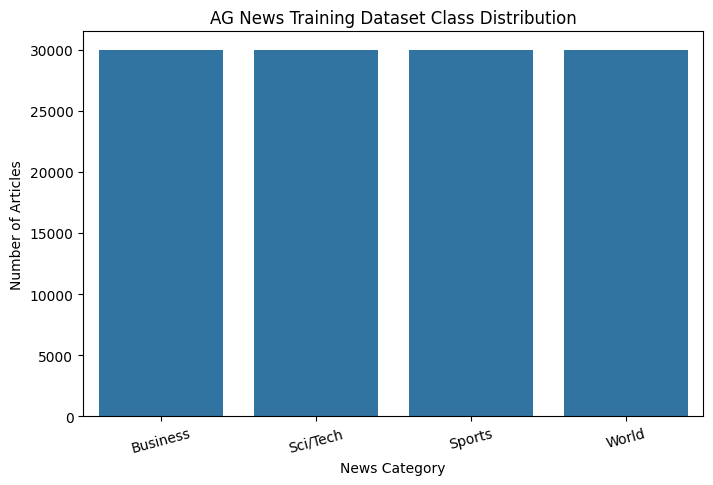

In [5]:
# Visualize class distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x="category")
plt.title("AG News Training Dataset Class Distribution")
plt.xlabel("News Category")
plt.ylabel("Number of Articles")
plt.xticks(rotation=15)
plt.show()

## 2. Inspect the Text Data

Before preprocessing, we inspect a few examples to understand the structure of the input text.


In [6]:
# Display sample articles
for i in range(5):
    print(f"Example {i+1}")
    print("Category:", train_df.loc[i, "category"])
    print("Text:", train_df.loc[i, "text"])
    print("-" * 100)

Example 1
Category: Business
Text: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
----------------------------------------------------------------------------------------------------
Example 2
Category: Business
Text: Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.
----------------------------------------------------------------------------------------------------
Example 3
Category: Business
Text: Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.
------------------------------------------------

## 3. Train-Validation-Test Split

The original AG News training data is divided into:
- **Training set:** 90%
- **Validation set:** 10%
- **Test set:** Official AG News test data

The validation set is used during training to monitor generalization, while the test set is used only for the final evaluation.


In [7]:
# Separate input text and labels
X = train_df["text"].astype(str).values
y = train_df["label"].values

X_test = test_df["text"].astype(str).values
y_test = test_df["label"].values

# Stratified split keeps class proportions approximately equal
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

print("Training samples :", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples     :", len(X_test))

Training samples : 108000
Validation samples: 12000
Test samples     : 7600


## 4. Text Preprocessing and Tokenization

A neural network cannot directly process raw text. The `TextVectorization` layer converts text into integer token sequences.

Important parameters:
- **Maximum vocabulary size:** 20,000 words
- **Sequence length:** 150 tokens

Texts shorter than 150 tokens are padded, while longer texts are truncated. This gives every input the same shape and makes batch processing possible.


In [8]:
# Reproducibility
SEED = 42
tf.keras.utils.set_random_seed(SEED)

# Text vectorization
MAX_VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 150

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_SEQUENCE_LENGTH,
    standardize="lower_and_strip_punctuation"
)

# Learn vocabulary only from training text
vectorizer.adapt(tf.data.Dataset.from_tensor_slices(X_train).batch(256))

vocab = vectorizer.get_vocabulary()

print("Vocabulary size:", len(vocab))
print("First 20 tokens:", vocab[:20])

Vocabulary size: 20000
First 20 tokens: ['', '[UNK]', np.str_('the'), np.str_('to'), np.str_('a'), np.str_('of'), np.str_('in'), np.str_('and'), np.str_('on'), np.str_('for'), np.str_('39s'), np.str_('that'), np.str_('with'), np.str_('as'), np.str_('at'), np.str_('its'), np.str_('is'), np.str_('new'), np.str_('by'), np.str_('said')]


In [9]:
# Convert text to padded integer sequences
X_train_seq = vectorizer(tf.constant(X_train))
X_val_seq = vectorizer(tf.constant(X_val))
X_test_seq = vectorizer(tf.constant(X_test))

print("Training tensor shape :", X_train_seq.shape)
print("Validation tensor shape:", X_val_seq.shape)
print("Test tensor shape     :", X_test_seq.shape)
print("\nExample padded sequence:")
print(X_train_seq[0].numpy())

Training tensor shape : (108000, 150)
Validation tensor shape: (12000, 150)
Test tensor shape     : (7600, 150)

Example padded sequence:
[ 162 1697   11  632 2590  325 1992 1697 3631   87  804    3 1926    4
 7821 5620    4 5899  199    2 2507  101    2    1   37   78    2 2739
 1076    7  592  511    1   14   34 4497    7 8725  121    2 6471 2389
  994   20   16   13  145    2 2518  703  725    3 1128    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0]


## 5. Build the Embedding + LSTM Model

### Architecture
1. **Embedding Layer:** Learns a dense vector representation for each word.
2. **LSTM Layer:** Learns sequential relationships and contextual information in the text.
3. **Dropout:** Helps reduce overfitting.
4. **Dense + Softmax:** Produces probabilities for the four news categories.

The model uses `sparse_categorical_crossentropy` because the target labels are integer class IDs (0, 1, 2, 3).


In [10]:
# Model hyperparameters
EMBEDDING_DIM = 128
LSTM_UNITS = 128
NUM_CLASSES = 4

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(MAX_SEQUENCE_LENGTH,), dtype=tf.int64),
    tf.keras.layers.Embedding(
        input_dim=MAX_VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),
    tf.keras.layers.LSTM(LSTM_UNITS),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,692,100 (10.27 MB)

 Trainable params: 2,692,100 (10.27 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Model

The model is trained for multiple epochs. `EarlyStopping` stops training when validation loss stops improving and restores the best model weights. This helps reduce overfitting and avoids unnecessary training.


In [11]:
# Train the LSTM model
EPOCHS = 10
BATCH_SIZE = 128

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 555s 653ms/step - accuracy: 0.8767 - loss: 0.3597 - val_accuracy: 0.9198 - val_loss: 0.2563
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 553s 643ms/step - accuracy: 0.9312 - loss: 0.2192 - val_accuracy: 0.9171 - val_loss: 0.2594
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 556s 636ms/step - accuracy: 0.9436 - loss: 0.1757 - val_accuracy: 0.9110 - val_loss: 0.2816


## 7. Plot Training and Validation Performance

These curves help us determine whether the model is learning effectively and whether there are signs of overfitting.


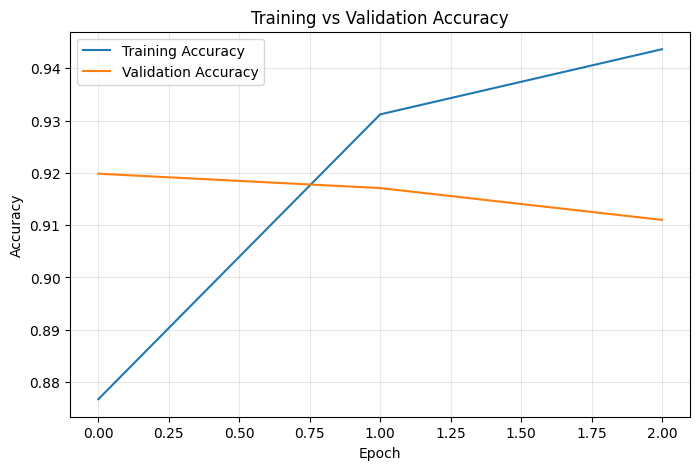

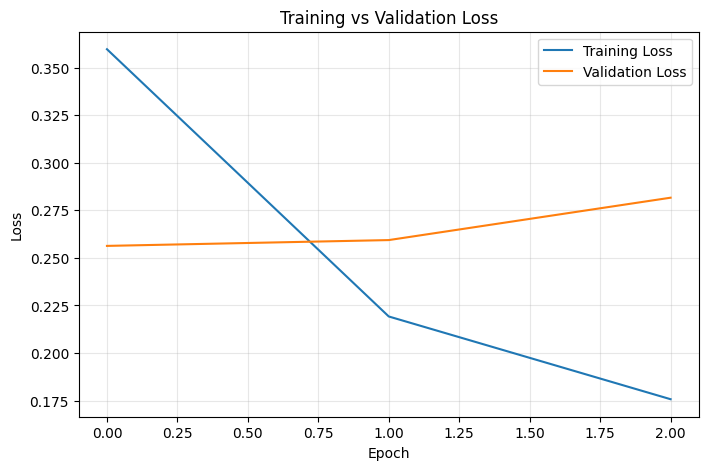

In [12]:
# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Final Evaluation on the Test Set

The official test set is used only after model training. We calculate accuracy, precision, recall, and F1-score.

- **Precision:** How many predicted samples of a class are actually that class.
- **Recall:** How many actual samples of a class are correctly identified.
- **F1-score:** Harmonic mean of precision and recall.
- **Accuracy:** Overall proportion of correct predictions.


In [13]:
# Evaluate loss and accuracy on the official test set
test_loss, test_accuracy = model.evaluate(
    X_test_seq,
    y_test,
    batch_size=BATCH_SIZE,
    verbose=0
)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

Test Loss     : 0.2675
Test Accuracy : 0.9151


In [14]:
# Generate predictions
y_prob = model.predict(X_test_seq, batch_size=BATCH_SIZE, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# Classification metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [accuracy, precision, recall, f1]
})

metrics_df["Score"] = metrics_df["Score"].round(4)
display(metrics_df)

,Metric,Score
0,Accuracy,0.9151
1,Precision,0.9154
2,Recall,0.9151
3,F1-Score,0.9150


## 9. Detailed Classification Report

The classification report provides precision, recall, and F1-score separately for each news category.


In [15]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       World     0.9390    0.8916    0.9147      1900
      Sports     0.9553    0.9789    0.9670      1900
    Business     0.8854    0.8826    0.8840      1900
    Sci/Tech     0.8818    0.9074    0.8944      1900

    accuracy                         0.9151      7600
   macro avg     0.9154    0.9151    0.9150      7600
weighted avg     0.9154    0.9151    0.9150      7600



## 10. Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions for each class. The diagonal represents correctly classified articles, while off-diagonal values represent classification errors.


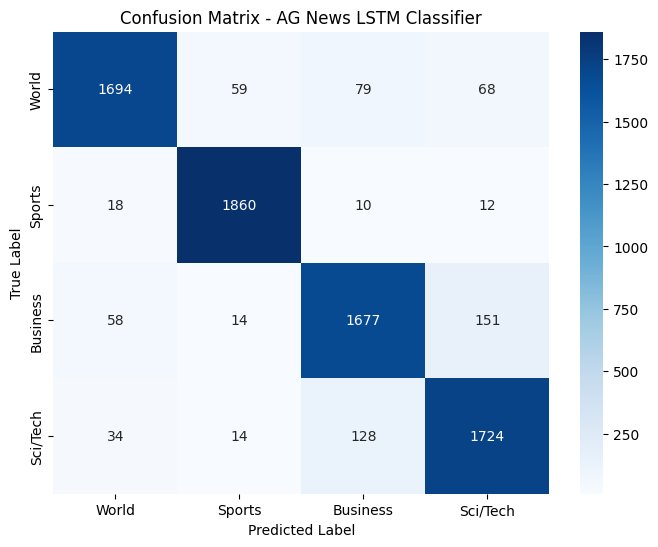

In [16]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Confusion Matrix - AG News LSTM Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## 11. Sample Predictions

The following examples show the original news text, actual category, predicted category, and prediction confidence.


In [17]:
# Show sample predictions
sample_indices = np.random.default_rng(SEED).choice(
    len(X_test), size=10, replace=False
)

prediction_rows = []

for idx in sample_indices:
    predicted_class = int(y_pred[idx])
    confidence = float(y_prob[idx][predicted_class])

    prediction_rows.append({
        "Text": X_test[idx][:180] + ("..." if len(X_test[idx]) > 180 else ""),
        "Actual": class_names[int(y_test[idx])],
        "Predicted": class_names[predicted_class],
        "Confidence": round(confidence, 4)
    })

predictions_df = pd.DataFrame(prediction_rows)
display(predictions_df)

,Text,Actual,Predicted,Confidence
0,"No Evidence Of Abuse At Guantanamo, says Austr...",World,World,0.9943
1,Novell NetWare users get Microsofts Offer With...,Sci/Tech,Sci/Tech,0.9707
2,Breast scans 'fail' in some women Some women w...,World,Sci/Tech,0.9407
3,Report: Drugs Caused Ken Caminiti #39;s Death ...,Sports,Sports,0.9889
4,Stern: #39;I #39;m tired of censorship #39;; ...,Business,Business,0.8978
5,Low-Income Lending Won #39;t Take A Hit Will l...,Business,Business,0.9548
6,ATI launches new Radeon Xpress 200 chipsets fo...,Sci/Tech,Sci/Tech,0.9854
7,Astronaut Candidates Practice Survival Skills ...,Sci/Tech,Sci/Tech,0.9824
8,How airlines stand Here #39;s where some of th...,Business,Business,0.9553
9,#39;Designer #39; Christmas tree growers targ...,Business,Business,0.9659


## 12. Error Analysis

Examining incorrect predictions is useful because some news articles can contain vocabulary that overlaps multiple categories. For example, a business article may mention technology companies, or a world-news article may discuss sports events.

The following cell displays a few misclassified examples.


In [18]:
# Display some misclassified examples
wrong_indices = np.where(y_test != y_pred)[0]

print("Number of incorrect predictions:", len(wrong_indices))

for idx in wrong_indices[:10]:
    print("Actual   :", class_names[int(y_test[idx])])
    print("Predicted:", class_names[int(y_pred[idx])])
    print("Text     :", X_test[idx][:300])
    print("-" * 100)

Number of incorrect predictions: 645
Actual   : Sci/Tech
Predicted: Business
Text     : Card fraud unit nets 36,000 cards In its first two years, the UK's dedicated card fraud unit, has recovered 36,000 stolen cards and 171 arrests - and estimates it saved 65m.
----------------------------------------------------------------------------------------------------
Actual   : Sci/Tech
Predicted: Business
Text     : IBM to hire even more new workers By the end of the year, the computing giant plans to have its biggest headcount since 1991.
----------------------------------------------------------------------------------------------------
Actual   : Sci/Tech
Predicted: Business
Text     : Some People Not Eligible to Get in on Google IPO Google has billed its IPO as a way for everyday people to get in on the process, denying Wall Street the usual stranglehold it's had on IPOs. Public bidding, a minimum of just five shares, an open process with 28 underwriters - all this pointed to a n
-------

## 13. Results and Conclusion

### Result
The Embedding + LSTM network successfully learns sequential patterns in AG News articles and performs multi-class classification across four categories.

The final performance should be reported using the values printed above for:
- Test Accuracy
- Weighted Precision
- Weighted Recall
- Weighted F1-score

### Conclusion
This assignment demonstrates a complete deep-learning text classification pipeline. Raw news articles were converted into numerical sequences using text vectorization, represented using a trainable Embedding layer, and processed by an LSTM network to capture sequential information. Dropout was used to reduce overfitting, and the final Dense/Softmax layer produced probabilities for the four news categories.

The model was evaluated on unseen test data using accuracy, precision, recall, F1-score, a classification report, and a confusion matrix. These metrics provide a more complete assessment than accuracy alone, especially for understanding class-wise performance.

**Therefore, an Embedding + LSTM architecture is effective for multi-class text classification and provides a strong baseline for sequence-based NLP tasks.**
